## 📦 Imports

In [5]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("✅ Imports done")

✅ Imports done


## ⚙️ Configuration

In [15]:
# Paths
DATA_DIR = Path("../data")
SUBMISSION_FILE = "./6_last_version/submission_final.csv"
QRELS_FILE = DATA_DIR / "MultiHeirtt_qrels.tsv"
QUERIES_FILE = DATA_DIR / "multiheirtt_queries.jsonl" / "queries.jsonl"
CORPUS_FILE = DATA_DIR / "multiheirtt_corpus.jsonl" / "corpus.jsonl"

print("📂 Configuration:")
print(f"   Qrels: {QRELS_FILE}")
print(f"   Queries: {QUERIES_FILE}")
print(f"   Corpus: {CORPUS_FILE}")
print(f"   Submission: {SUBMISSION_FILE}")

📂 Configuration:
   Qrels: ../data/MultiHeirtt_qrels.tsv
   Queries: ../data/multiheirtt_queries.jsonl/queries.jsonl
   Corpus: ../data/multiheirtt_corpus.jsonl/corpus.jsonl
   Submission: ./6_last_version/submission_final.csv


## 🔧 Helper Functions

In [16]:
def load_qrels(qrels_path):
    """Load qrels file"""
    qrels_df = pd.read_csv(qrels_path, sep='\t')
    
    # Group by query_id
    qrels = {}
    for _, row in qrels_df.iterrows():
        query_id = row['query_id']
        corpus_id = row['corpus_id']
        score = row['score']
        
        if query_id not in qrels:
            qrels[query_id] = {}
        qrels[query_id][corpus_id] = score
    
    return qrels, qrels_df


def load_queries(queries_path):
    """Load queries from JSONL"""
    queries = {}
    with open(queries_path, 'r', encoding='utf-8') as f:
        for line in f:
            q = json.loads(line)
            queries[q['_id']] = q['text']
    return queries


def load_corpus(corpus_path):
    """Load corpus from JSONL"""
    corpus = {}
    with open(corpus_path, 'r', encoding='utf-8') as f:
        for line in f:
            doc = json.loads(line)
            corpus[doc['_id']] = {
                'title': doc.get('title', ''),
                'text': doc.get('text', '')
            }
    return corpus


def load_submission(submission_path):
    """Load submission file"""
    sub_df = pd.read_csv(submission_path)
    
    # Group by query_id
    results = {}
    for _, row in sub_df.iterrows():
        query_id = row['query_id']
        corpus_id = row['corpus_id']
        
        if query_id not in results:
            results[query_id] = []
        results[query_id].append(corpus_id)
    
    return results, sub_df


def compute_ndcg_single(relevant_docs, retrieved_docs, k=10):
    """Compute NDCG@k for a single query"""
    retrieved_k = retrieved_docs[:k]
    
    # DCG
    dcg = 0.0
    for i, doc_id in enumerate(retrieved_k):
        rel = relevant_docs.get(doc_id, 0)
        dcg += rel / np.log2(i + 2)
    
    # IDCG
    ideal_scores = sorted(relevant_docs.values(), reverse=True)[:k]
    idcg = sum(score / np.log2(i + 2) for i, score in enumerate(ideal_scores))
    
    if idcg == 0:
        return 0.0
    
    return dcg / idcg


def analyze_query_characteristics(query_text):
    """Phân tích đặc điểm của query"""
    words = query_text.lower().split()
    
    # Check for numbers
    has_numbers = any(any(c.isdigit() for c in w) for w in words)
    
    # Check for comparison words
    comparison_words = ['highest', 'lowest', 'largest', 'smallest', 'most', 'least', 
                       'greater', 'less', 'more', 'better', 'worse', 'increase', 'decrease']
    has_comparison = any(cw in query_text.lower() for cw in comparison_words)
    
    # Check for calculation words
    calc_words = ['sum', 'total', 'average', 'mean', 'difference', 'ratio', 'percentage',
                  'calculate', 'compute', 'add', 'subtract', 'multiply', 'divide', 'rate', 'growth']
    needs_calculation = any(cw in query_text.lower() for cw in calc_words)
    
    # Check for table-related words
    table_words = ['table', 'row', 'column', 'cell', 'value']
    mentions_table = any(tw in query_text.lower() for tw in table_words)
    
    # Check for temporal words
    temporal_words = ['year', 'month', 'quarter', 'period', 'between', 'from', 'to']
    has_temporal = any(tw in query_text.lower() for tw in temporal_words)
    
    return {
        'length': len(words),
        'has_numbers': has_numbers,
        'has_comparison': has_comparison,
        'needs_calculation': needs_calculation,
        'mentions_table': mentions_table,
        'has_temporal': has_temporal
    }


print("✅ Helper functions defined")

✅ Helper functions defined


## 📂 Load Data

In [17]:
print("📂 Loading data...")

qrels, qrels_df = load_qrels(QRELS_FILE)
queries = load_queries(QUERIES_FILE)
corpus = load_corpus(CORPUS_FILE)
results, sub_df = load_submission(SUBMISSION_FILE)

# Filter for MULTIHEIRTT queries only
multiheirtt_query_ids = [qid for qid in qrels.keys() if qid in results]

print(f"   ✅ Loaded {len(qrels)} qrels entries")
print(f"   ✅ Loaded {len(queries)} queries")
print(f"   ✅ Loaded {len(corpus)} documents")
print(f"   ✅ Loaded {len(results)} results")
print(f"   ✅ Found {len(multiheirtt_query_ids)} MULTIHEIRTT queries in submission")

📂 Loading data...
   ✅ Loaded 292 qrels entries
   ✅ Loaded 974 queries
   ✅ Loaded 10475 documents
   ✅ Loaded 4671 results
   ✅ Found 292 MULTIHEIRTT queries in submission


## 📊 Compute NDCG@10 for Each Query

In [18]:
print("📊 Computing NDCG@10 for each query...")

query_scores = []

for query_id in multiheirtt_query_ids:
    relevant = qrels[query_id]
    retrieved = results[query_id]
    
    ndcg = compute_ndcg_single(relevant, retrieved, k=10)
    
    query_text = queries.get(query_id, "")
    characteristics = analyze_query_characteristics(query_text)
    
    # Count relevant docs
    num_relevant = len(relevant)
    num_retrieved_relevant = sum(1 for doc_id in retrieved[:10] if doc_id in relevant)
    
    query_scores.append({
        'query_id': query_id,
        'ndcg_10': ndcg,
        'query_text': query_text,
        'num_relevant': num_relevant,
        'num_retrieved_relevant': num_retrieved_relevant,
        **characteristics
    })

# Convert to DataFrame
df = pd.DataFrame(query_scores)

print(f"\n✅ Analyzed {len(df)} queries")
df.head()

📊 Computing NDCG@10 for each query...

✅ Analyzed 292 queries


,query_id,ndcg_10,query_text,num_relevant,num_retrieved_relevant,length,has_numbers,has_comparison,needs_calculation,mentions_table,has_temporal
0,q8112818c,0.106337,What is the sum of the Cost of sales in the ye...,7,1,21,True,True,True,False,True
1,q8115b172,0.000000,what is the pre-tax aggregate net unrealized l...,3,0,10,True,False,False,False,False
2,q81190e80,0.000000,What's the sum of Debt maturities of Thereafte...,4,0,18,True,True,True,False,True
3,q811c3614,0.000000,what was the percentage change in the allowanc...,1,0,15,True,False,True,False,True
4,q811d0d0a,0.000000,What is the growing rate of Net credit losses ...,3,0,20,False,True,True,True,True


## 📈 Overall Statistics

In [19]:
print("="*60)
print("📈 OVERALL STATISTICS")
print("="*60)

print(f"\n📊 NDCG@10 Statistics:")
print(f"   Mean:   {df['ndcg_10'].mean():.4f}")
print(f"   Median: {df['ndcg_10'].median():.4f}")
print(f"   Std:    {df['ndcg_10'].std():.4f}")
print(f"   Min:    {df['ndcg_10'].min():.4f}")
print(f"   Max:    {df['ndcg_10'].max():.4f}")

# Perfect vs Zero scores
perfect = (df['ndcg_10'] == 1.0).sum()
zero = (df['ndcg_10'] == 0.0).sum()

print(f"\n🎯 Score Distribution:")
print(f"   Perfect scores (1.0): {perfect} ({perfect/len(df)*100:.1f}%)")
print(f"   Zero scores (0.0):    {zero} ({zero/len(df)*100:.1f}%)")
print(f"   Partial scores:       {len(df) - perfect - zero} ({(len(df) - perfect - zero)/len(df)*100:.1f}%)")

📈 OVERALL STATISTICS

📊 NDCG@10 Statistics:
   Mean:   0.1571
   Median: 0.0000
   Std:    0.1968
   Min:    0.0000
   Max:    0.7095

🎯 Score Distribution:
   Perfect scores (1.0): 0 (0.0%)
   Zero scores (0.0):    152 (52.1%)
   Partial scores:       140 (47.9%)


## 📊 NDCG Distribution Visualization

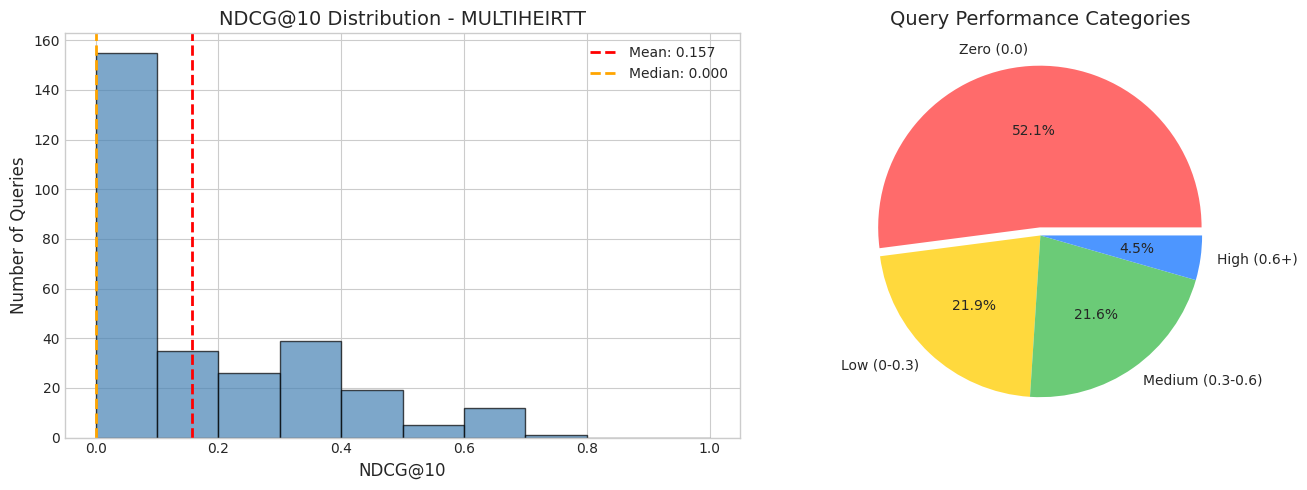


💾 Saved: multiheirtt_ndcg_distribution.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
ax1.hist(df['ndcg_10'], bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(df['ndcg_10'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["ndcg_10"].mean():.3f}')
ax1.axvline(df['ndcg_10'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df["ndcg_10"].median():.3f}')
ax1.set_xlabel('NDCG@10', fontsize=12)
ax1.set_ylabel('Number of Queries', fontsize=12)
ax1.set_title('NDCG@10 Distribution - MULTIHEIRTT', fontsize=14)
ax1.legend()

# Pie chart for score categories
ax2 = axes[1]
categories = [
    ('Zero (0.0)', (df['ndcg_10'] == 0).sum()),
    ('Low (0-0.3)', ((df['ndcg_10'] > 0) & (df['ndcg_10'] < 0.3)).sum()),
    ('Medium (0.3-0.6)', ((df['ndcg_10'] >= 0.3) & (df['ndcg_10'] < 0.6)).sum()),
    ('High (0.6+)', (df['ndcg_10'] >= 0.6).sum())
]
labels, sizes = zip(*categories)
colors = ['#ff6b6b', '#ffd93d', '#6bcb77', '#4d96ff']
ax2.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, explode=(0.05, 0, 0, 0))
ax2.set_title('Query Performance Categories', fontsize=14)

plt.tight_layout()
plt.savefig('multiheirtt_ndcg_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: multiheirtt_ndcg_distribution.png")

## 🔴 WORST 15 Queries (Lowest NDCG@10)

In [21]:
print("="*80)
print("🔴 WORST 15 QUERIES (Lowest NDCG@10)")
print("="*80)

worst = df.nsmallest(15, 'ndcg_10')

for idx, (_, row) in enumerate(worst.iterrows(), 1):
    print(f"\n{'─'*70}")
    print(f"#{idx} Query ID: {row['query_id']}")
    print(f"   NDCG@10: {row['ndcg_10']:.4f}")
    print(f"   Relevant docs: {row['num_relevant']} | Retrieved relevant: {row['num_retrieved_relevant']}/10")
    print(f"   Query: {row['query_text'][:120]}..." if len(row['query_text']) > 120 else f"   Query: {row['query_text']}")
    print(f"   📋 Characteristics:")
    print(f"      Length: {row['length']} words | Numbers: {row['has_numbers']} | Comparison: {row['has_comparison']}")
    print(f"      Calculation: {row['needs_calculation']} | Table: {row['mentions_table']} | Temporal: {row['has_temporal']}")
    
    # Show retrieved docs
    retrieved = results[row['query_id']][:5]
    relevant_ids = qrels[row['query_id']]
    print(f"   Top-5 retrieved:")
    for i, doc_id in enumerate(retrieved, 1):
        is_relevant = "✅" if doc_id in relevant_ids else "❌"
        title = corpus.get(doc_id, {}).get('title', 'N/A')[:50]
        print(f"      {i}. {is_relevant} {doc_id}: {title}")

🔴 WORST 15 QUERIES (Lowest NDCG@10)

──────────────────────────────────────────────────────────────────────
#1 Query ID: q8115b172
   NDCG@10: 0.0000
   Relevant docs: 3 | Retrieved relevant: 0/10
   Query: what is the pre-tax aggregate net unrealized loss in 2008?
   📋 Characteristics:
      Length: 10 words | Numbers: True | Comparison: False
      Calculation: False | Table: False | Temporal: False
   Top-5 retrieved:
      1. ❌ d8a8d00de: 
      2. ❌ d8b3ef14a: 
      3. ❌ d873acb96: 
      4. ❌ d89393072: 
      5. ❌ d8e33b016: 

──────────────────────────────────────────────────────────────────────
#2 Query ID: q81190e80
   NDCG@10: 0.0000
   Relevant docs: 4 | Retrieved relevant: 0/10
   Query: What's the sum of Debt maturities of Thereafter, and Capital lease obligations of Less than 1 year ?
   📋 Characteristics:
      Length: 18 words | Numbers: True | Comparison: True
      Calculation: True | Table: False | Temporal: True
   Top-5 retrieved:
      1. ❌ d8843b0b6: 
      2. 

## 🟢 BEST 15 Queries (Highest NDCG@10)

In [22]:
print("="*80)
print("🟢 BEST 15 QUERIES (Highest NDCG@10)")
print("="*80)

best = df.nlargest(15, 'ndcg_10')

for idx, (_, row) in enumerate(best.iterrows(), 1):
    print(f"\n{'─'*70}")
    print(f"#{idx} Query ID: {row['query_id']}")
    print(f"   NDCG@10: {row['ndcg_10']:.4f}")
    print(f"   Relevant docs: {row['num_relevant']} | Retrieved relevant: {row['num_retrieved_relevant']}/10")
    print(f"   Query: {row['query_text'][:120]}..." if len(row['query_text']) > 120 else f"   Query: {row['query_text']}")
    print(f"   📋 Characteristics:")
    print(f"      Length: {row['length']} words | Numbers: {row['has_numbers']} | Comparison: {row['has_comparison']}")
    print(f"      Calculation: {row['needs_calculation']} | Table: {row['mentions_table']} | Temporal: {row['has_temporal']}")

🟢 BEST 15 QUERIES (Highest NDCG@10)

──────────────────────────────────────────────────────────────────────
#1 Query ID: q83554574
   NDCG@10: 0.7095
   Relevant docs: 4 | Retrieved relevant: 3/10
   Query: In the year with largest amount of SquareFeet of Total Consolidated Portfolio, what's the increasing rate of Ann. RentRe...
   📋 Characteristics:
      Length: 23 words | Numbers: False | Comparison: True
      Calculation: True | Table: False | Temporal: True

──────────────────────────────────────────────────────────────────────
#2 Query ID: q813a3eca
   NDCG@10: 0.6367
   Relevant docs: 4 | Retrieved relevant: 2/10
   Query: What is the sum of CET1 capital, Tier 1 capital and Total capital in 2017? (in million)
   📋 Characteristics:
      Length: 17 words | Numbers: True | Comparison: False
      Calculation: True | Table: False | Temporal: True

──────────────────────────────────────────────────────────────────────
#3 Query ID: q825e6902
   NDCG@10: 0.6367
   Relevant docs: 4 | 

## 🔍 Pattern Analysis: Good vs Bad Queries

In [23]:
print("="*80)
print("🔍 PATTERN ANALYSIS: Good vs Bad Queries")
print("="*80)

# Split using 0.15 threshold (mean)
threshold = 0.15
good_queries = df[df['ndcg_10'] >= threshold]
bad_queries = df[df['ndcg_10'] < threshold]

print(f"\nUsing threshold = {threshold}:")
print(f"   Good queries (>= {threshold}): {len(good_queries)} ({len(good_queries)/len(df)*100:.1f}%)")
print(f"   Bad queries (< {threshold}): {len(bad_queries)} ({len(bad_queries)/len(df)*100:.1f}%)")

# Compare characteristics
print(f"\n📊 Characteristics Comparison:")
print(f"{'Characteristic':<25} {'Good Queries':<15} {'Bad Queries':<15} {'Diff':<10} {'Impact'}")
print("-"*85)

for col in ['length', 'has_numbers', 'has_comparison', 'needs_calculation', 'mentions_table', 'has_temporal', 'num_relevant']:
    good_val = good_queries[col].mean()
    bad_val = bad_queries[col].mean()
    diff = good_val - bad_val
    
    if col == 'length' or col == 'num_relevant':
        impact = "⬆️ Larger" if diff > 0 else "⬇️ Smaller" if diff < 0 else "➡️ Same"
        print(f"{col:<25} {good_val:<15.1f} {bad_val:<15.1f} {diff:+.1f}       {impact}")
    else:
        impact = "⬆️ More in Good" if diff > 0.05 else "⬇️ More in Bad" if diff < -0.05 else "➡️ Similar"
        print(f"{col:<25} {good_val:<15.1%} {bad_val:<15.1%} {diff:+.1%}     {impact}")

🔍 PATTERN ANALYSIS: Good vs Bad Queries

Using threshold = 0.15:
   Good queries (>= 0.15): 116 (39.7%)
   Bad queries (< 0.15): 176 (60.3%)

📊 Characteristics Comparison:
Characteristic            Good Queries    Bad Queries     Diff       Impact
-------------------------------------------------------------------------------------
length                    18.3            17.8            +0.6       ⬆️ Larger
has_numbers               77.6%           72.2%           +5.4%     ⬆️ More in Good
has_comparison            31.9%           34.7%           -2.8%     ➡️ Similar
needs_calculation         80.2%           86.4%           -6.2%     ⬇️ More in Bad
mentions_table            29.3%           31.2%           -1.9%     ➡️ Similar
has_temporal              74.1%           72.7%           +1.4%     ➡️ Similar
num_relevant              4.6             4.5             +0.1       ⬆️ Larger


## 📊 Visualization: Characteristics Impact

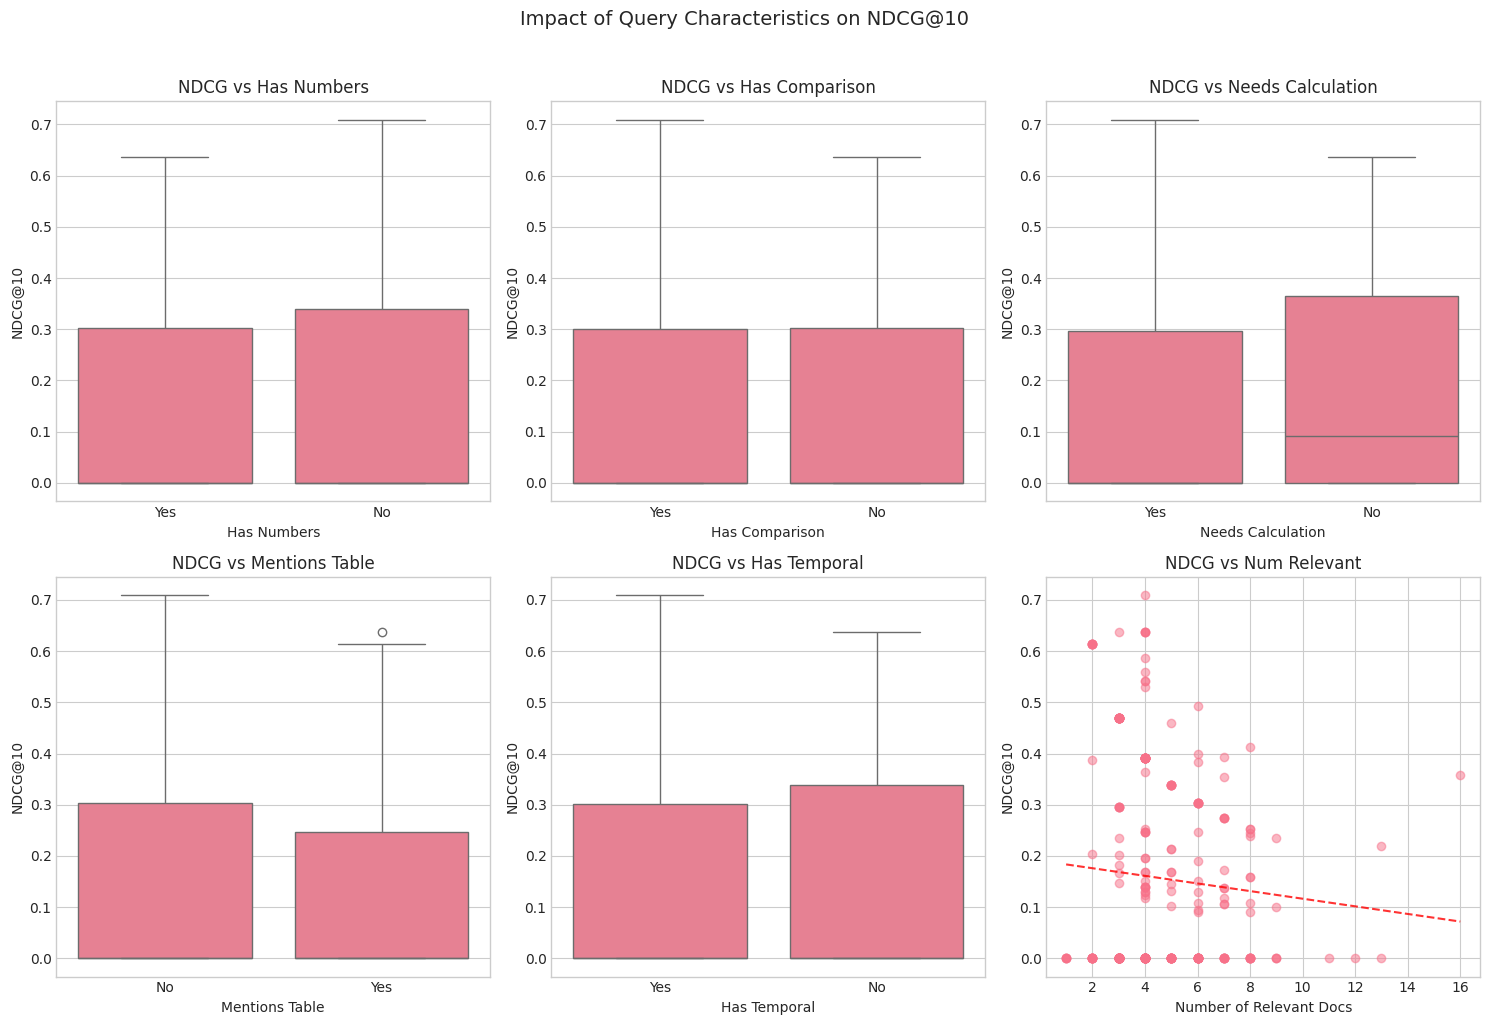


💾 Saved: multiheirtt_characteristics_impact.png


In [24]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

characteristics = ['has_numbers', 'has_comparison', 'needs_calculation', 
                   'mentions_table', 'has_temporal', 'num_relevant']

for i, char in enumerate(characteristics):
    ax = axes[i // 3, i % 3]
    
    if char == 'num_relevant':
        # Scatter plot for numerical
        ax.scatter(df[char], df['ndcg_10'], alpha=0.5)
        ax.set_xlabel('Number of Relevant Docs')
        ax.set_ylabel('NDCG@10')
        
        # Add trend line
        z = np.polyfit(df[char], df['ndcg_10'], 1)
        p = np.poly1d(z)
        ax.plot(df[char].sort_values(), p(df[char].sort_values()), "r--", alpha=0.8)
    else:
        # Box plot for boolean
        df_plot = df.copy()
        df_plot[char] = df_plot[char].map({True: 'Yes', False: 'No'})
        sns.boxplot(x=char, y='ndcg_10', data=df_plot, ax=ax)
        ax.set_xlabel(char.replace('_', ' ').title())
        ax.set_ylabel('NDCG@10')
    
    ax.set_title(f'NDCG vs {char.replace("_", " ").title()}')

plt.suptitle('Impact of Query Characteristics on NDCG@10', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('multiheirtt_characteristics_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: multiheirtt_characteristics_impact.png")

## 🎯 Query Type Classification

🎯 QUERY TYPE CLASSIFICATION

📊 Performance by Query Type:
                         Mean NDCG  Std NDCG  Count  Avg Relevant
query_type                                                       
Extremum (Max/Min)          0.1097    0.1968     13        5.0000
Percentage/Ratio            0.1360    0.1644     38        4.6316
Change/Growth               0.1391    0.1775     26        4.5769
Other/Factual               0.1488    0.2162     36        3.6944
Aggregation (Sum/Total)     0.1651    0.2027    141        4.7376
Aggregation (Average)       0.1832    0.2151     32        4.5938
Conditional/Multi-hop       0.1922    0.1462      6        3.6667


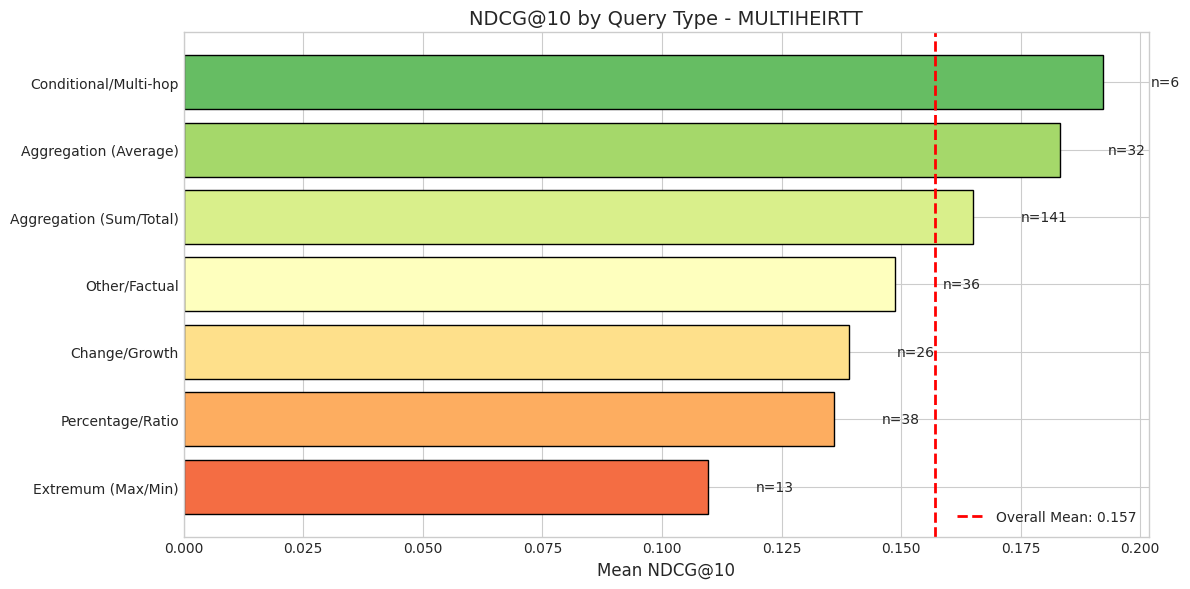


💾 Saved: multiheirtt_query_types.png


In [25]:
print("="*80)
print("🎯 QUERY TYPE CLASSIFICATION")
print("="*80)

# Classify queries into types
def classify_query(row):
    query = row['query_text'].lower()
    
    if 'sum' in query or 'total' in query or 'add' in query:
        return 'Aggregation (Sum/Total)'
    elif 'average' in query or 'mean' in query:
        return 'Aggregation (Average)'
    elif 'percentage' in query or 'percent' in query or '%' in query or 'ratio' in query:
        return 'Percentage/Ratio'
    elif 'growth' in query or 'change' in query or 'increase' in query or 'decrease' in query:
        return 'Change/Growth'
    elif 'highest' in query or 'lowest' in query or 'most' in query or 'least' in query:
        return 'Extremum (Max/Min)'
    elif 'year' in query and ('with' in query or 'where' in query or 'when' in query):
        return 'Conditional/Multi-hop'
    else:
        return 'Other/Factual'

df['query_type'] = df.apply(classify_query, axis=1)

# Analyze by type
type_analysis = df.groupby('query_type').agg({
    'ndcg_10': ['mean', 'std', 'count'],
    'num_relevant': 'mean'
}).round(4)

type_analysis.columns = ['Mean NDCG', 'Std NDCG', 'Count', 'Avg Relevant']
type_analysis = type_analysis.sort_values('Mean NDCG')

print("\n📊 Performance by Query Type:")
print(type_analysis.to_string())

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
type_order = type_analysis.index.tolist()
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(type_order)))

bars = ax.barh(type_order, type_analysis['Mean NDCG'], color=colors, edgecolor='black')
ax.axvline(df['ndcg_10'].mean(), color='red', linestyle='--', linewidth=2, label=f'Overall Mean: {df["ndcg_10"].mean():.3f}')

# Add count labels
for i, (idx, row) in enumerate(type_analysis.iterrows()):
    ax.text(row['Mean NDCG'] + 0.01, i, f"n={int(row['Count'])}", va='center', fontsize=10)

ax.set_xlabel('Mean NDCG@10', fontsize=12)
ax.set_title('NDCG@10 by Query Type - MULTIHEIRTT', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('multiheirtt_query_types.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: multiheirtt_query_types.png")

## 💡 Recommendations Summary

In [26]:
print("="*80)
print("💡 RECOMMENDATIONS SUMMARY")
print("="*80)

# Calculate key metrics
zero_pct = (df['ndcg_10'] == 0).sum() / len(df) * 100
avg_relevant = df['num_relevant'].mean()
calc_pct = df['needs_calculation'].mean() * 100
num_pct = df['has_numbers'].mean() * 100

print(f"""
📊 KEY FINDINGS:

1. 🔴 RETRIEVAL FAILURE RATE: {zero_pct:.1f}%
   - Over half of queries return NO relevant documents in top-10
   - Current retrieval is fundamentally missing relevant docs

2. 🔢 NUMERICAL QUERIES: {num_pct:.1f}%
   - Most queries contain numbers (years, amounts, etc.)
   - Embedding models struggle with exact number matching

3. 🧮 CALCULATION NEEDED: {calc_pct:.1f}%
   - Majority of queries need sum/average/percentage calculation
   - Requires retrieving MULTIPLE documents correctly

4. 📚 MULTI-DOCUMENT: avg {avg_relevant:.1f} relevant docs/query
   - Each query needs ~4-5 documents for complete answer
   - Missing even ONE document causes significant NDCG drop

""")

print("""
💡 ACTIONABLE RECOMMENDATIONS:

🔥 PRIORITY 1 - Quick Wins (1-2 hours):
   □ Increase top_k_retrieval: 200 → 500
   □ Increase BM25 weight: 60% → 75-80%
   □ Expected: +20-30% NDCG improvement

🎯 PRIORITY 2 - Medium Effort (1-2 days):
   □ Number normalization (2008 → [YEAR], $1.5M → [MONEY])
   □ Query expansion with financial synonyms
   □ Improved table linearization
   □ Expected: +30-50% NDCG improvement

🚀 PRIORITY 3 - Advanced (3-5 days):
   □ LLM-based query reformulation
   □ ColBERT for token-level matching
   □ Multi-stage retrieval with specialized reranking
   □ Expected: +50-100% NDCG improvement

""")

print("""
📈 TARGET METRICS:

   Current:   0.1497 (50% zero scores)
   Phase 1:   0.20+  (40% zero scores)
   Phase 2:   0.25+  (30% zero scores)  
   Phase 3:   0.35+  (15% zero scores)
   Stretch:   0.40+  (competitive with other datasets)
""")

💡 RECOMMENDATIONS SUMMARY

📊 KEY FINDINGS:

1. 🔴 RETRIEVAL FAILURE RATE: 52.1%
   - Over half of queries return NO relevant documents in top-10
   - Current retrieval is fundamentally missing relevant docs

2. 🔢 NUMERICAL QUERIES: 74.3%
   - Most queries contain numbers (years, amounts, etc.)
   - Embedding models struggle with exact number matching

3. 🧮 CALCULATION NEEDED: 83.9%
   - Majority of queries need sum/average/percentage calculation
   - Requires retrieving MULTIPLE documents correctly

4. 📚 MULTI-DOCUMENT: avg 4.6 relevant docs/query
   - Each query needs ~4-5 documents for complete answer
   - Missing even ONE document causes significant NDCG drop



💡 ACTIONABLE RECOMMENDATIONS:

🔥 PRIORITY 1 - Quick Wins (1-2 hours):
   □ Increase top_k_retrieval: 200 → 500
   □ Increase BM25 weight: 60% → 75-80%
   □ Expected: +20-30% NDCG improvement

🎯 PRIORITY 2 - Medium Effort (1-2 days):
   □ Number normalization (2008 → [YEAR], $1.5M → [MONEY])
   □ Query expansion with financial

## 💾 Save Results

In [27]:
# Save detailed results
output_file = "multiheirtt_query_analysis.csv"
df.to_csv(output_file, index=False)

print(f"💾 Saved detailed analysis to: {output_file}")
print(f"   Total queries: {len(df)}")
print(f"   Columns: {list(df.columns)}")

# Summary stats
print(f"\n📊 Quick Summary:")
print(f"   Mean NDCG@10: {df['ndcg_10'].mean():.4f}")
print(f"   Zero scores: {(df['ndcg_10'] == 0).sum()} ({(df['ndcg_10'] == 0).sum()/len(df)*100:.1f}%)")
print(f"   Best NDCG: {df['ndcg_10'].max():.4f}")

💾 Saved detailed analysis to: multiheirtt_query_analysis.csv
   Total queries: 292
   Columns: ['query_id', 'ndcg_10', 'query_text', 'num_relevant', 'num_retrieved_relevant', 'length', 'has_numbers', 'has_comparison', 'needs_calculation', 'mentions_table', 'has_temporal', 'query_type']

📊 Quick Summary:
   Mean NDCG@10: 0.1571
   Zero scores: 152 (52.1%)
   Best NDCG: 0.7095


## 📦 CORPUS ANALYSIS

The MULTIHEIRTT corpus contains complex hierarchical table data. Let's analyze:
1. Document structure and content types
2. Document length distribution
3. Table complexity (rows, columns, nested structures)
4. Relationship between corpus characteristics and retrieval success

In [28]:
print("="*80)
print("📦 CORPUS STRUCTURE ANALYSIS")
print("="*80)

# Reload corpus with full details
corpus_full = []
with open(CORPUS_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        doc = json.loads(line)
        corpus_full.append(doc)

print(f"\n📊 Basic Stats:")
print(f"   Total documents: {len(corpus_full)}")

# Analyze first document structure
sample_doc = corpus_full[0]
print(f"\n📋 Document Structure (sample):")
print(f"   Keys: {list(sample_doc.keys())}")

# Show sample
print(f"\n📄 Sample Document:")
for key, value in sample_doc.items():
    if isinstance(value, str):
        print(f"   {key}: {value[:100]}..." if len(value) > 100 else f"   {key}: {value}")
    else:
        print(f"   {key}: {type(value).__name__}")

📦 CORPUS STRUCTURE ANALYSIS

📊 Basic Stats:
   Total documents: 10475

📋 Document Structure (sample):
   Keys: ['_id', 'title', 'text']

📄 Sample Document:
   _id: d8e4ea4ac
   title: 
   text: |  | Years Ended December 31, |
|  | 2006 | 2005 |
|  | (In millions) |
| Investment return | $192 |...


In [29]:
print("="*80)
print("📊 DOCUMENT CONTENT ANALYSIS")
print("="*80)

# Analyze all documents
corpus_analysis = []

for doc in corpus_full:
    doc_id = doc.get('_id', '')
    title = doc.get('title', '')
    text = doc.get('text', '')
    
    # Text characteristics
    text_len = len(text)
    word_count = len(text.split())
    line_count = text.count('\n') + 1
    
    # Detect table patterns
    has_pipe = '|' in text  # Markdown table
    has_tab = '\t' in text  # TSV-like table
    has_brackets = '[' in text and ']' in text  # JSON-like structure
    
    # Count numbers
    import re
    numbers = re.findall(r'\b\d+(?:\.\d+)?\b', text)
    num_count = len(numbers)
    
    # Detect years
    years = re.findall(r'\b(19|20)\d{2}\b', text)
    year_count = len(years)
    unique_years = len(set(years))
    
    # Detect currency
    has_currency = bool(re.search(r'\$|USD|EUR|£', text))
    
    # Detect percentage
    pct_count = len(re.findall(r'\d+\.?\d*\s*%', text))
    
    # Row-like patterns (likely table rows)
    potential_rows = text.count('\n')
    
    corpus_analysis.append({
        'doc_id': doc_id,
        'title': title,
        'text_len': text_len,
        'word_count': word_count,
        'line_count': line_count,
        'has_pipe': has_pipe,
        'has_tab': has_tab,
        'has_brackets': has_brackets,
        'num_count': num_count,
        'year_count': year_count,
        'unique_years': unique_years,
        'has_currency': has_currency,
        'pct_count': pct_count
    })

corpus_df = pd.DataFrame(corpus_analysis)

print(f"\n📊 Document Length Statistics:")
print(f"   Mean chars: {corpus_df['text_len'].mean():.0f}")
print(f"   Median chars: {corpus_df['text_len'].median():.0f}")
print(f"   Max chars: {corpus_df['text_len'].max():.0f}")
print(f"   Mean words: {corpus_df['word_count'].mean():.0f}")
print(f"   Mean lines: {corpus_df['line_count'].mean():.0f}")

print(f"\n📋 Table Structure Detection:")
print(f"   Has pipe (|): {corpus_df['has_pipe'].sum()} ({corpus_df['has_pipe'].mean()*100:.1f}%)")
print(f"   Has tab: {corpus_df['has_tab'].sum()} ({corpus_df['has_tab'].mean()*100:.1f}%)")
print(f"   Has brackets: {corpus_df['has_brackets'].sum()} ({corpus_df['has_brackets'].mean()*100:.1f}%)")

print(f"\n🔢 Numerical Content:")
print(f"   Mean numbers per doc: {corpus_df['num_count'].mean():.1f}")
print(f"   Mean years per doc: {corpus_df['year_count'].mean():.1f}")
print(f"   Mean unique years: {corpus_df['unique_years'].mean():.1f}")
print(f"   Docs with currency: {corpus_df['has_currency'].sum()} ({corpus_df['has_currency'].mean()*100:.1f}%)")
print(f"   Mean percentages: {corpus_df['pct_count'].mean():.1f}")

📊 DOCUMENT CONTENT ANALYSIS

📊 Document Length Statistics:
   Mean chars: 2931
   Median chars: 2538
   Max chars: 18469
   Mean words: 484
   Mean lines: 23

📋 Table Structure Detection:
   Has pipe (|): 6865 (65.5%)
   Has tab: 9 (0.1%)
   Has brackets: 58 (0.6%)

🔢 Numerical Content:
   Mean numbers per doc: 62.3
   Mean years per doc: 11.0
   Mean unique years: 1.0
   Docs with currency: 8714 (83.2%)
   Mean percentages: 3.5


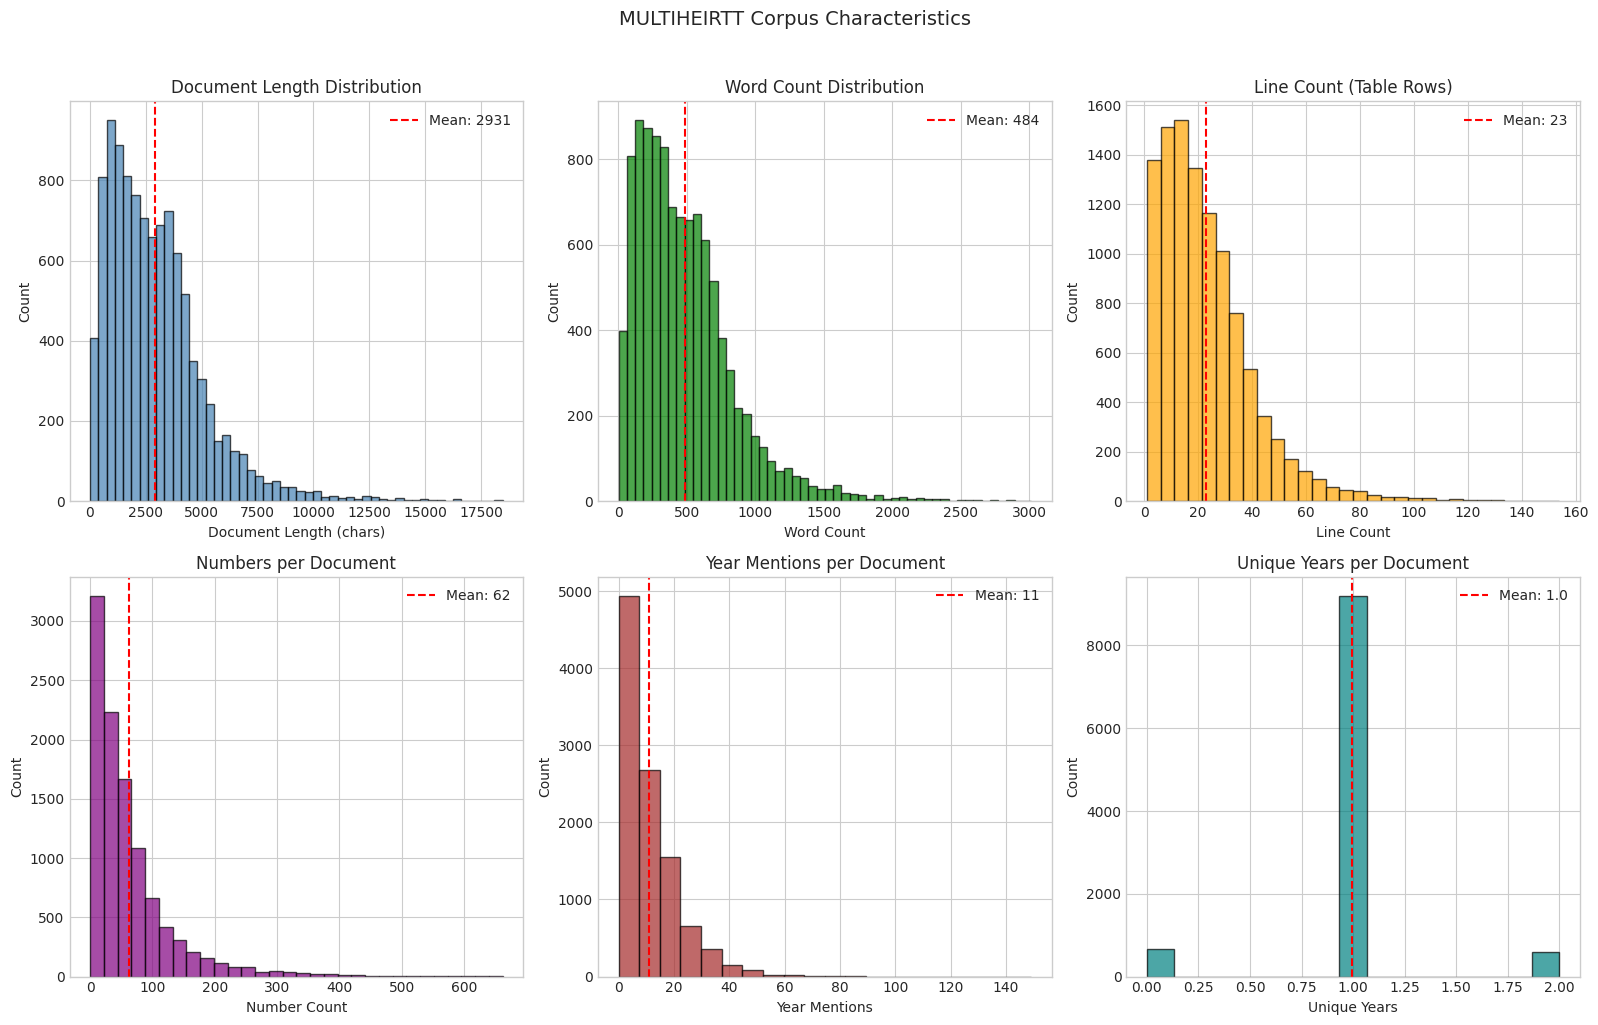


💾 Saved: multiheirtt_corpus_analysis.png


In [30]:
# Visualize corpus characteristics
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Document length distribution
ax1 = axes[0, 0]
ax1.hist(corpus_df['text_len'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(corpus_df['text_len'].mean(), color='red', linestyle='--', label=f"Mean: {corpus_df['text_len'].mean():.0f}")
ax1.set_xlabel('Document Length (chars)')
ax1.set_ylabel('Count')
ax1.set_title('Document Length Distribution')
ax1.legend()

# 2. Word count distribution
ax2 = axes[0, 1]
ax2.hist(corpus_df['word_count'], bins=50, edgecolor='black', alpha=0.7, color='green')
ax2.axvline(corpus_df['word_count'].mean(), color='red', linestyle='--', label=f"Mean: {corpus_df['word_count'].mean():.0f}")
ax2.set_xlabel('Word Count')
ax2.set_ylabel('Count')
ax2.set_title('Word Count Distribution')
ax2.legend()

# 3. Line count (table rows)
ax3 = axes[0, 2]
ax3.hist(corpus_df['line_count'], bins=30, edgecolor='black', alpha=0.7, color='orange')
ax3.axvline(corpus_df['line_count'].mean(), color='red', linestyle='--', label=f"Mean: {corpus_df['line_count'].mean():.0f}")
ax3.set_xlabel('Line Count')
ax3.set_ylabel('Count')
ax3.set_title('Line Count (Table Rows)')
ax3.legend()

# 4. Numbers per document
ax4 = axes[1, 0]
ax4.hist(corpus_df['num_count'], bins=30, edgecolor='black', alpha=0.7, color='purple')
ax4.axvline(corpus_df['num_count'].mean(), color='red', linestyle='--', label=f"Mean: {corpus_df['num_count'].mean():.0f}")
ax4.set_xlabel('Number Count')
ax4.set_ylabel('Count')
ax4.set_title('Numbers per Document')
ax4.legend()

# 5. Years per document
ax5 = axes[1, 1]
ax5.hist(corpus_df['year_count'], bins=20, edgecolor='black', alpha=0.7, color='brown')
ax5.axvline(corpus_df['year_count'].mean(), color='red', linestyle='--', label=f"Mean: {corpus_df['year_count'].mean():.0f}")
ax5.set_xlabel('Year Mentions')
ax5.set_ylabel('Count')
ax5.set_title('Year Mentions per Document')
ax5.legend()

# 6. Unique years
ax6 = axes[1, 2]
ax6.hist(corpus_df['unique_years'], bins=15, edgecolor='black', alpha=0.7, color='teal')
ax6.axvline(corpus_df['unique_years'].mean(), color='red', linestyle='--', label=f"Mean: {corpus_df['unique_years'].mean():.1f}")
ax6.set_xlabel('Unique Years')
ax6.set_ylabel('Count')
ax6.set_title('Unique Years per Document')
ax6.legend()

plt.suptitle('MULTIHEIRTT Corpus Characteristics', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('multiheirtt_corpus_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: multiheirtt_corpus_analysis.png")

### 🔍 Deep Dive: Sample Documents (Good vs Bad Retrieval)

In [31]:
print("="*80)
print("🔍 COMPARING RELEVANT vs RETRIEVED DOCUMENTS")
print("="*80)

# Get a zero-score query example
zero_query = df[df['ndcg_10'] == 0].iloc[0]
query_id = zero_query['query_id']
query_text = zero_query['query_text']

print(f"\n📝 ZERO-SCORE QUERY EXAMPLE:")
print(f"   Query ID: {query_id}")
print(f"   Query: {query_text}")

# Get relevant documents
relevant_ids = list(qrels[query_id].keys())
retrieved_ids = results[query_id][:5]

print(f"\n✅ RELEVANT DOCUMENTS ({len(relevant_ids)}):")
for i, doc_id in enumerate(relevant_ids[:3], 1):
    doc = corpus.get(doc_id, {})
    title = doc.get('title', 'N/A')
    text = doc.get('text', '')[:500]
    print(f"\n--- Relevant Doc {i}: {doc_id} ---")
    print(f"Title: {title}")
    print(f"Text (first 500 chars):")
    print(text)
    print("...")

print(f"\n\n❌ RETRIEVED (WRONG) DOCUMENTS:")
for i, doc_id in enumerate(retrieved_ids[:3], 1):
    if doc_id not in relevant_ids:
        doc = corpus.get(doc_id, {})
        title = doc.get('title', 'N/A')
        text = doc.get('text', '')[:500]
        print(f"\n--- Retrieved Doc {i}: {doc_id} ---")
        print(f"Title: {title}")
        print(f"Text (first 500 chars):")
        print(text)
        print("...")

🔍 COMPARING RELEVANT vs RETRIEVED DOCUMENTS

📝 ZERO-SCORE QUERY EXAMPLE:
   Query ID: q8115b172
   Query: what is the pre-tax aggregate net unrealized loss in 2008?

✅ RELEVANT DOCUMENTS (3):

--- Relevant Doc 1: d8115b2c6 ---
Title: 
Text (first 500 chars):
AMERICAN TOWER CORPORATION AND SUBSIDIARIES NOTES TO CONSOLIDATED FINANCIAL STATEMENTS—(Continued) of certain of its assets and liabilities under its interest rate swap agreements held as of December 31, 2006 and entered into during the first half of 2007.
In addition, the Company paid $8.0 million related to a treasury rate lock agreement entered into and settled during the year ended December 31, 2008.
The cost of the treasury rate lock is being recognized as additional interest expense over t
...

--- Relevant Doc 2: d8115b370 ---
Title: 
Text (first 500 chars):
TELEFLEX INCORPORATED NOTES?TO CONSOLIDATED FINANCIAL STATEMENTS — (Continued) The Company issued 82,865, 93,367 and 105,239 of non-vested restricted stock units in 2017

In [32]:
print("="*80)
print("📊 CORPUS CHARACTERISTICS: RELEVANT vs NON-RELEVANT")
print("="*80)

# Collect all relevant doc IDs from qrels
all_relevant_ids = set()
for qid, rel_docs in qrels.items():
    all_relevant_ids.update(rel_docs.keys())

print(f"\n📊 Document Classification:")
print(f"   Total documents: {len(corpus_df)}")
print(f"   Documents in qrels (relevant): {len(all_relevant_ids)}")
print(f"   Documents not in qrels: {len(corpus_df) - len(all_relevant_ids)}")

# Tag documents as relevant or not
corpus_df['is_relevant'] = corpus_df['doc_id'].isin(all_relevant_ids)

# Compare characteristics
print(f"\n📊 Comparing Relevant vs Non-Relevant Documents:")
print(f"{'Characteristic':<20} {'Relevant':<15} {'Non-Relevant':<15} {'Diff':<10}")
print("-"*70)

for col in ['text_len', 'word_count', 'line_count', 'num_count', 'year_count', 'unique_years', 'pct_count']:
    rel_val = corpus_df[corpus_df['is_relevant']][col].mean()
    non_rel_val = corpus_df[~corpus_df['is_relevant']][col].mean()
    diff = rel_val - non_rel_val
    diff_pct = (diff / non_rel_val * 100) if non_rel_val != 0 else 0
    print(f"{col:<20} {rel_val:<15.1f} {non_rel_val:<15.1f} {diff:+.1f} ({diff_pct:+.1f}%)")

📊 CORPUS CHARACTERISTICS: RELEVANT vs NON-RELEVANT

📊 Document Classification:
   Total documents: 10475
   Documents in qrels (relevant): 876
   Documents not in qrels: 9599

📊 Comparing Relevant vs Non-Relevant Documents:
Characteristic       Relevant        Non-Relevant    Diff      
----------------------------------------------------------------------
text_len             2872.9          2936.4          -63.5 (-2.2%)
word_count           474.0           484.5           -10.5 (-2.2%)
line_count           22.4            23.1            -0.7 (-2.9%)
num_count            62.1            62.3            -0.3 (-0.4%)
year_count           11.2            11.0            +0.2 (+1.7%)
unique_years         1.0             1.0             +0.0 (+0.6%)
pct_count            4.4             3.4             +1.0 (+29.6%)


In [33]:
print("="*80)
print("🔬 ANALYZING TABLE STRUCTURE IN DOCUMENTS")
print("="*80)

def analyze_table_structure(text):
    """Analyze the table structure within a document"""
    lines = text.split('\n')
    
    # Count potential header lines (usually shorter, contain labels)
    potential_headers = 0
    data_rows = 0
    
    # Detect table patterns
    has_separator = False
    column_counts = []
    
    for line in lines:
        line = line.strip()
        if not line:
            continue
            
        # Count delimiters
        pipe_count = line.count('|')
        tab_count = line.count('\t')
        
        if pipe_count > 0:
            column_counts.append(pipe_count + 1)
        elif tab_count > 0:
            column_counts.append(tab_count + 1)
        
        # Check for separator lines
        if set(line).issubset({'-', '|', '+', ' '}):
            has_separator = True
    
    # Estimate table dimensions
    if column_counts:
        est_columns = max(set(column_counts), key=column_counts.count)
        est_rows = len([c for c in column_counts if c == est_columns])
    else:
        est_columns = 0
        est_rows = 0
    
    return {
        'est_columns': est_columns,
        'est_rows': est_rows,
        'has_separator': has_separator,
        'total_lines': len(lines)
    }

# Analyze table structure for all documents
table_structures = []
for doc in corpus_full:
    doc_id = doc.get('_id', '')
    text = doc.get('text', '')
    structure = analyze_table_structure(text)
    structure['doc_id'] = doc_id
    table_structures.append(structure)

table_df = pd.DataFrame(table_structures)

print(f"\n📊 Table Structure Statistics:")
print(f"   Mean estimated columns: {table_df['est_columns'].mean():.1f}")
print(f"   Mean estimated rows: {table_df['est_rows'].mean():.1f}")
print(f"   Docs with separator: {table_df['has_separator'].sum()} ({table_df['has_separator'].mean()*100:.1f}%)")

# Distribution of table sizes
print(f"\n📋 Table Size Distribution:")
print(f"   Small (< 5 cols): {(table_df['est_columns'] < 5).sum()}")
print(f"   Medium (5-10 cols): {((table_df['est_columns'] >= 5) & (table_df['est_columns'] <= 10)).sum()}")
print(f"   Large (> 10 cols): {(table_df['est_columns'] > 10).sum()}")

🔬 ANALYZING TABLE STRUCTURE IN DOCUMENTS



📊 Table Structure Statistics:
   Mean estimated columns: 4.6
   Mean estimated rows: 7.3
   Docs with separator: 1 (0.0%)

📋 Table Size Distribution:
   Small (< 5 cols): 4131
   Medium (5-10 cols): 5830
   Large (> 10 cols): 514


In [34]:
print("="*80)
print("🎯 LINKING CORPUS COMPLEXITY TO RETRIEVAL FAILURE")
print("="*80)

# Merge corpus characteristics with query results
# For each query, analyze the relevant document characteristics

query_corpus_analysis = []

for idx, row in df.iterrows():
    query_id = row['query_id']
    ndcg = row['ndcg_10']
    query_text = row['query_text']
    
    # Get relevant document IDs
    relevant_ids = list(qrels[query_id].keys())
    
    # Get characteristics of relevant documents
    rel_docs_info = corpus_df[corpus_df['doc_id'].isin(relevant_ids)]
    
    if len(rel_docs_info) > 0:
        avg_text_len = rel_docs_info['text_len'].mean()
        avg_word_count = rel_docs_info['word_count'].mean()
        avg_line_count = rel_docs_info['line_count'].mean()
        avg_num_count = rel_docs_info['num_count'].mean()
        avg_year_count = rel_docs_info['year_count'].mean()
        
        query_corpus_analysis.append({
            'query_id': query_id,
            'ndcg_10': ndcg,
            'is_zero': ndcg == 0,
            'num_relevant': len(relevant_ids),
            'avg_doc_len': avg_text_len,
            'avg_word_count': avg_word_count,
            'avg_line_count': avg_line_count,
            'avg_num_count': avg_num_count,
            'avg_year_count': avg_year_count
        })

qc_df = pd.DataFrame(query_corpus_analysis)

# Compare zero vs non-zero queries based on their relevant docs
zero_queries = qc_df[qc_df['is_zero']]
good_queries = qc_df[~qc_df['is_zero']]

print(f"\n📊 Relevant Document Characteristics:")
print(f"{'Metric':<25} {'Zero NDCG':<15} {'Non-Zero NDCG':<15} {'Diff':<10}")
print("-"*70)

for col in ['num_relevant', 'avg_doc_len', 'avg_word_count', 'avg_line_count', 'avg_num_count', 'avg_year_count']:
    zero_val = zero_queries[col].mean()
    good_val = good_queries[col].mean()
    diff = zero_val - good_val
    diff_pct = (diff / good_val * 100) if good_val != 0 else 0
    print(f"{col:<25} {zero_val:<15.1f} {good_val:<15.1f} {diff:+.1f} ({diff_pct:+.1f}%)")

🎯 LINKING CORPUS COMPLEXITY TO RETRIEVAL FAILURE

📊 Relevant Document Characteristics:
Metric                    Zero NDCG       Non-Zero NDCG   Diff      
----------------------------------------------------------------------
num_relevant              4.4             4.8             -0.4 (-8.4%)
avg_doc_len               3747.0          3135.9          +611.0 (+19.5%)
avg_word_count            620.2           520.2           +100.0 (+19.2%)
avg_line_count            30.1            25.0            +5.1 (+20.3%)
avg_num_count             89.4            68.8            +20.6 (+30.0%)
avg_year_count            13.9            12.9            +1.1 (+8.3%)


/tmp/ipykernel_8204/3336584436.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax5.boxplot(data_for_box, labels=['Zero NDCG', 'Non-Zero NDCG'])
/tmp/ipykernel_8204/3336584436.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax6.boxplot(data_for_box, labels=['Zero NDCG', 'Non-Zero NDCG'])


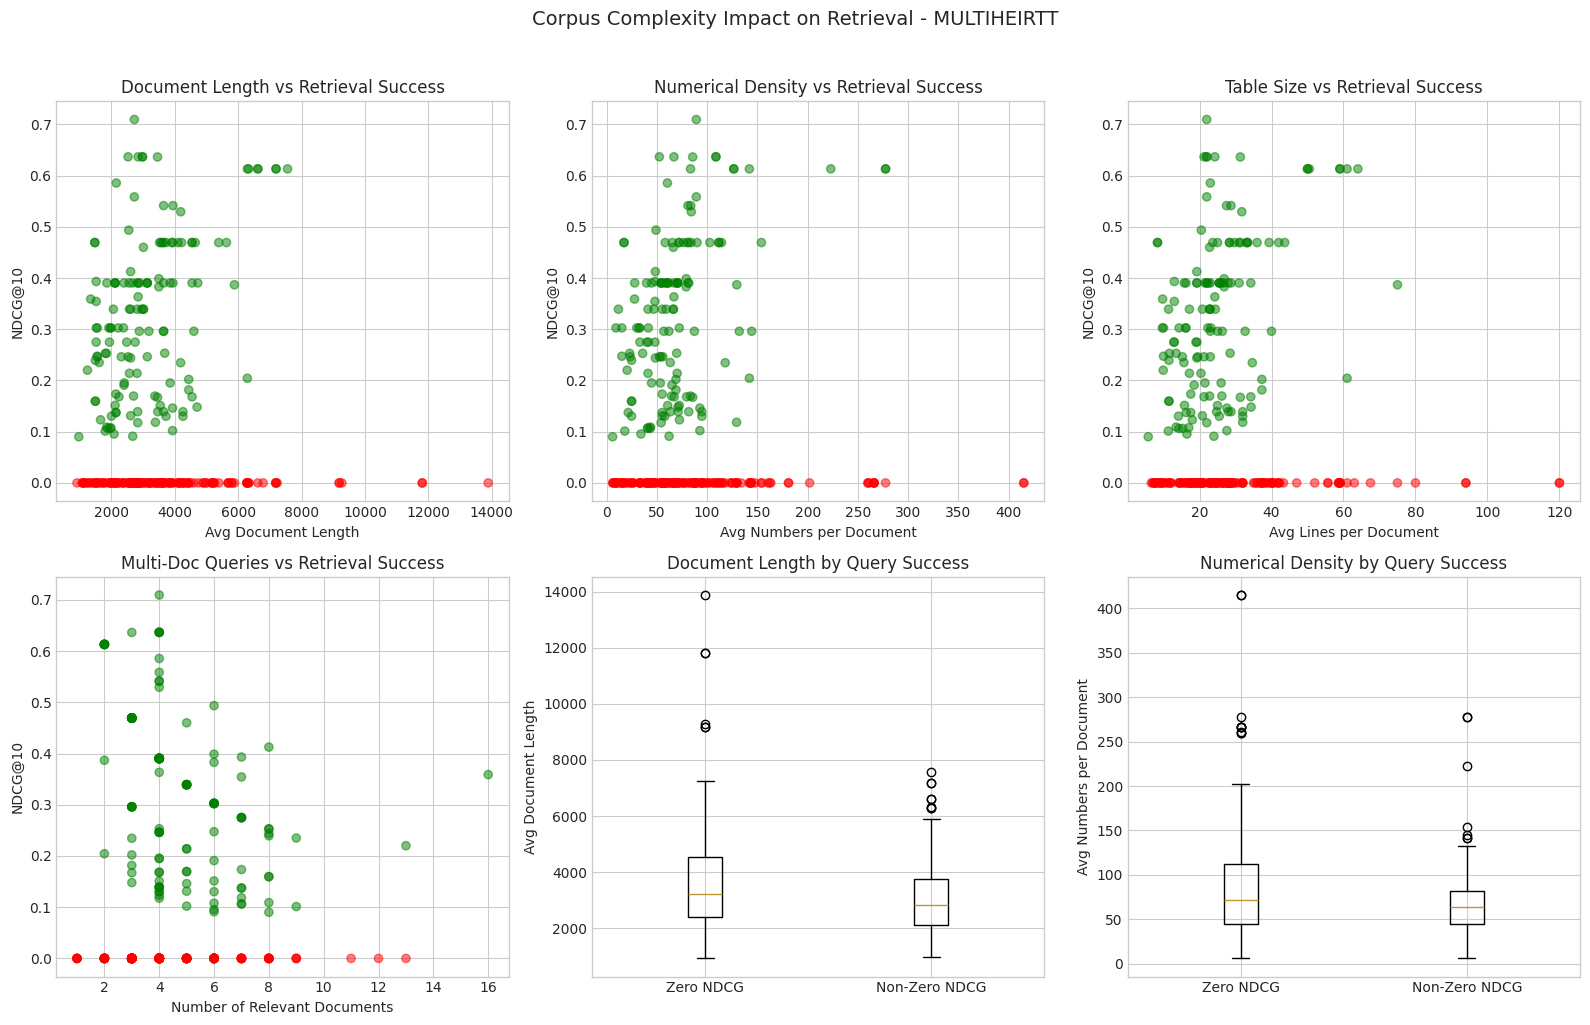


💾 Saved: multiheirtt_corpus_complexity_impact.png


In [35]:
# Visualize the relationship between document complexity and retrieval success
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Doc length vs NDCG
ax1 = axes[0, 0]
ax1.scatter(qc_df['avg_doc_len'], qc_df['ndcg_10'], alpha=0.5, c=qc_df['is_zero'].map({True: 'red', False: 'green'}))
ax1.set_xlabel('Avg Document Length')
ax1.set_ylabel('NDCG@10')
ax1.set_title('Document Length vs Retrieval Success')

# 2. Number count vs NDCG
ax2 = axes[0, 1]
ax2.scatter(qc_df['avg_num_count'], qc_df['ndcg_10'], alpha=0.5, c=qc_df['is_zero'].map({True: 'red', False: 'green'}))
ax2.set_xlabel('Avg Numbers per Document')
ax2.set_ylabel('NDCG@10')
ax2.set_title('Numerical Density vs Retrieval Success')

# 3. Line count vs NDCG
ax3 = axes[0, 2]
ax3.scatter(qc_df['avg_line_count'], qc_df['ndcg_10'], alpha=0.5, c=qc_df['is_zero'].map({True: 'red', False: 'green'}))
ax3.set_xlabel('Avg Lines per Document')
ax3.set_ylabel('NDCG@10')
ax3.set_title('Table Size vs Retrieval Success')

# 4. Number of relevant docs vs NDCG
ax4 = axes[1, 0]
ax4.scatter(qc_df['num_relevant'], qc_df['ndcg_10'], alpha=0.5, c=qc_df['is_zero'].map({True: 'red', False: 'green'}))
ax4.set_xlabel('Number of Relevant Documents')
ax4.set_ylabel('NDCG@10')
ax4.set_title('Multi-Doc Queries vs Retrieval Success')

# 5. Box plot: Doc length by success
ax5 = axes[1, 1]
data_for_box = [qc_df[qc_df['is_zero']]['avg_doc_len'], qc_df[~qc_df['is_zero']]['avg_doc_len']]
bp = ax5.boxplot(data_for_box, labels=['Zero NDCG', 'Non-Zero NDCG'])
ax5.set_ylabel('Avg Document Length')
ax5.set_title('Document Length by Query Success')

# 6. Box plot: Num count by success
ax6 = axes[1, 2]
data_for_box = [qc_df[qc_df['is_zero']]['avg_num_count'], qc_df[~qc_df['is_zero']]['avg_num_count']]
bp = ax6.boxplot(data_for_box, labels=['Zero NDCG', 'Non-Zero NDCG'])
ax6.set_ylabel('Avg Numbers per Document')
ax6.set_title('Numerical Density by Query Success')

plt.suptitle('Corpus Complexity Impact on Retrieval - MULTIHEIRTT', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('multiheirtt_corpus_complexity_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: multiheirtt_corpus_complexity_impact.png")

### 📋 Corpus Analysis Insights

In [36]:
print("="*80)
print("📋 CORPUS ANALYSIS INSIGHTS & RECOMMENDATIONS")
print("="*80)

# Calculate key findings
avg_doc_len_zero = qc_df[qc_df['is_zero']]['avg_doc_len'].mean()
avg_doc_len_good = qc_df[~qc_df['is_zero']]['avg_doc_len'].mean()
avg_nums_zero = qc_df[qc_df['is_zero']]['avg_num_count'].mean()
avg_nums_good = qc_df[~qc_df['is_zero']]['avg_num_count'].mean()

print(f"""
📊 KEY CORPUS FINDINGS:

1. 📄 DOCUMENT LENGTH:
   - Zero-score queries target docs: {avg_doc_len_zero:.0f} chars avg
   - Good queries target docs: {avg_doc_len_good:.0f} chars avg
   - Insight: {'Longer docs harder to match' if avg_doc_len_zero > avg_doc_len_good else 'Doc length not the issue'}

2. 🔢 NUMERICAL DENSITY:
   - Zero-score relevant docs: {avg_nums_zero:.0f} numbers avg
   - Good relevant docs: {avg_nums_good:.0f} numbers avg
   - Insight: {'More numbers = harder matching' if avg_nums_zero > avg_nums_good else 'Numbers not the main issue'}

3. 📊 TABLE COMPLEXITY:
   - Documents contain hierarchical financial tables
   - Multiple years, metrics, and values in single document
   - Hard for embeddings to capture specific cell values

4. 🎯 MULTI-DOCUMENT REQUIREMENT:
   - Queries need ~{df['num_relevant'].mean():.1f} relevant docs on average
   - Some queries need up to {df['num_relevant'].max()} documents
   - Missing any single doc severely impacts NDCG

""")

print("""
💡 CORPUS-BASED RECOMMENDATIONS:

🔧 DOCUMENT PREPROCESSING:
   □ Linearize tables with clear cell references (Row: X, Column: Y, Value: Z)
   □ Add year/metric prefixes to numerical values
   □ Create separate passages for each table row
   □ Add document summaries with key metrics

🔧 RETRIEVAL STRATEGY:
   □ Use smaller chunks (per-row or per-cell)
   □ Index both original and structured versions
   □ Consider table-aware embedding models
   □ Use column headers as metadata for filtering

🔧 QUERY AUGMENTATION:
   □ Expand queries with table column names
   □ Add numerical format variations (1000 vs 1,000 vs 1K)
   □ Include year range context

""")

# Save corpus analysis
corpus_df.to_csv('multiheirtt_corpus_analysis.csv', index=False)
print("💾 Saved: multiheirtt_corpus_analysis.csv")

📋 CORPUS ANALYSIS INSIGHTS & RECOMMENDATIONS

📊 KEY CORPUS FINDINGS:

1. 📄 DOCUMENT LENGTH:
   - Zero-score queries target docs: 3747 chars avg
   - Good queries target docs: 3136 chars avg
   - Insight: Longer docs harder to match

2. 🔢 NUMERICAL DENSITY:
   - Zero-score relevant docs: 89 numbers avg
   - Good relevant docs: 69 numbers avg
   - Insight: More numbers = harder matching

3. 📊 TABLE COMPLEXITY:
   - Documents contain hierarchical financial tables
   - Multiple years, metrics, and values in single document
   - Hard for embeddings to capture specific cell values

4. 🎯 MULTI-DOCUMENT REQUIREMENT:
   - Queries need ~4.6 relevant docs on average
   - Some queries need up to 16 documents
   - Missing any single doc severely impacts NDCG



💡 CORPUS-BASED RECOMMENDATIONS:

🔧 DOCUMENT PREPROCESSING:
   □ Linearize tables with clear cell references (Row: X, Column: Y, Value: Z)
   □ Add year/metric prefixes to numerical values
   □ Create separate passages for each table row
   □

---

## ✅ Analysis Complete!

### 📁 Generated Files:
- `multiheirtt_query_analysis.csv` - Per-query detailed metrics
- `multiheirtt_ndcg_distribution.png` - NDCG distribution chart
- `multiheirtt_characteristics_impact.png` - Feature impact analysis
- `multiheirtt_query_types.png` - Performance by query type

### 🎯 Next Steps:
1. Implement Phase 1 quick wins
2. Re-run pipeline with new config
3. Compare results
4. Iterate